<a href="https://colab.research.google.com/github/camgenomicmedicine/GMO4/blob/main/GMO4_Practical_9_RNAseq_Snakemake_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GMO4 Advanced Bioinformatics Practical 9 — Colab version

## RNA-seq pipelines with Snakemake: from FASTQ files to gene counts and differential expression

This is the **Google Colab** version of the RNA-seq pipeline practical. It installs the required RNA-seq software inside the Colab runtime and then runs the analysis through Snakemake.

In this practical you will move from the DNA variant-calling workflow into the RNA-seq expression-analysis workflow. You will:

1. upload a prepared course RNA-seq data archive into `/content`;
2. extract six cut-down yeast RNA-seq FASTQ files, a matching GTF annotation file and the yeast reference genome;
3. run FastQC;
4. build a HISAT2 splice-aware reference index;
5. align RNA-seq reads to the reference genome;
6. count reads per gene;
7. calculate CPM, FPKM and TPM;
8. perform differential gene expression analysis between respiratory and fermentative growth.

The data archive expected by this notebook is:

`GM04_AdvBioinfo_RNAseq_April2026.tar`

Upload that archive into `/content` using the Colab file manager before running the data setup cell.

As before, the emphasis is on understanding the steps, not just running commands.


## 0. The data

You will analyse six *Saccharomyces cerevisiae* RNA-seq samples: three respiratory-growth samples and three fermentative-growth samples.

For the at-home Colab version, the original public FASTQ files have been cut down and packaged into a smaller course archive:

`GM04_AdvBioinfo_RNAseq_April2026.tar`

The archive should contain:

- the yeast reference genome FASTA;
- the matching Ensembl release 68 GTF annotation file;
- a directory called `Counting/` containing the six `.fastq.gz` files.

The FASTQ filenames are the same as the original accessions:

| condition | sample IDs |
|---|---|
| respiratory growth | `ERR3994183`, `ERR3994185`, `ERR3994187` |
| fermentative growth | `ERR3994184`, `ERR3994186`, `ERR3994188` |

The notebook will copy those files into a clean working directory so that the Snakemake workflow can use consistent paths.


## 1. How this differs from the variant-calling workflow

Some ideas transfer directly from the DNA practicals. We still care about raw read quality, reference genomes, alignment, BAM files and reproducibility.

However, several variant-calling steps are not used here:

| DNA variant-calling practical | RNA-seq expression practical |
|---|---|
| BWA alignment to a genome | HISAT2 splice-aware alignment to a genome |
| Read groups are important for variant calling | Read groups are not central for simple gene-counting |
| Duplicate marking is often used before variant calling | Duplicate marking is usually not applied to ordinary RNA-seq counts because read depth is the signal, unless UMIs or a specific protocol require it |
| BQSR/local realignment/GATK-style BAM refinement | Not used for this simple gene-expression workflow |
| GATK/FreeBayes call variants | featureCounts assigns reads to genes |
| VCF filtering and comparison | count normalization and differential expression |

**Q1.** List three steps from the previous variant-calling workflow that are not needed for this RNA-seq expression workflow. For each one, write a short reason why it is not needed here.


## 2. Set up the Colab practical workspace

This practical creates a self-contained working directory called `/content/rnaseq_snakemake_practical`.

Colab runtimes are temporary. If the runtime disconnects or resets, you may need to rerun the setup and pipeline cells.


In [1]:

from pathlib import Path
import os

PROJECT_DIR = Path("/content/rnaseq_snakemake_practical")
ENV_PREFIX = Path("/content/rnaseq_env")
BIN_DIR = Path("/content/bin")

for subdir in [
    "config", "data/raw", "references", "scripts", "qc", "logs", "bams", "counts", "quant", "deseq2", "plots"
]:
    (PROJECT_DIR / subdir).mkdir(parents=True, exist_ok=True)
BIN_DIR.mkdir(parents=True, exist_ok=True)

os.environ["PROJECT_DIR"] = str(PROJECT_DIR)
os.environ["ENV_PREFIX"] = str(ENV_PREFIX)
os.environ["PATH"] = f"{ENV_PREFIX}/bin:{BIN_DIR}:" + os.environ.get("PATH", "")

print("PROJECT_DIR:", PROJECT_DIR)
print("ENV_PREFIX:", ENV_PREFIX)
print("BIN_DIR:", BIN_DIR)


PROJECT_DIR: /content/rnaseq_snakemake_practical
ENV_PREFIX: /content/rnaseq_env
BIN_DIR: /content/bin


## 3. Install the RNA-seq tools in Colab

The teaching VMs may already have many command-line tools available, but Colab starts with a general Python environment. This cell installs `micromamba` and then creates a local RNA-seq environment under `/content/rnaseq_env`.

This may take several minutes the first time you run it in a fresh Colab runtime.

Tools installed here include:

- `snakemake-minimal` for workflow execution;
- `fastqc` and `multiqc` for QC;
- `hisat2` for splice-aware RNA-seq alignment;
- `samtools` for BAM processing;
- `subread`, which provides `featureCounts`;
- `DESeq2` in R for differential expression;
- Python packages for the count-normalisation script;
- `graphviz` so Snakemake can draw the workflow DAG.


In [2]:

%%bash
set -euo pipefail

mkdir -p /content/bin
export PATH="/content/bin:$PATH"

if [ ! -x /content/bin/micromamba ]; then
  echo "Installing micromamba..."
  curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest \
    | tar -xvj -C /content/bin --strip-components=1 bin/micromamba
else
  echo "micromamba already present"
fi

export MAMBA_ROOT_PREFIX=/content/micromamba

if [ ! -x "$ENV_PREFIX/bin/snakemake" ]; then
  echo "Creating RNA-seq environment at $ENV_PREFIX"
  micromamba create -y -p "$ENV_PREFIX" \
    -c conda-forge -c bioconda \
    python=3.11 pandas numpy scipy matplotlib \
    snakemake-minimal fastqc multiqc hisat2 samtools subread graphviz wget curl pigz \
    r-base bioconductor-deseq2 r-ggplot2 r-readr r-dplyr r-tibble r-pheatmap
else
  echo "RNA-seq environment already exists at $ENV_PREFIX"
fi

echo
echo "Checking installed tools:"
export PATH="$ENV_PREFIX/bin:/content/bin:$PATH"
python --version
snakemake --version
fastqc --version
hisat2 --version | head -n 1
samtools --version | head -n 1
featureCounts -v 2>&1 | head -n 2 || true
Rscript -e 'suppressPackageStartupMessages(library(DESeq2)); cat("DESeq2 OK\n")'


Installing micromamba...
bin/micromamba
Creating RNA-seq environment at /content/rnaseq_env
⚠ Shard Index for bioconda/linux-64 not available, falling back to flat repodata
Using Flat Repodata for bioconda/linux-64                                                       ✔ Starting
Using Flat Repodata for bioconda/linux-64                                                 ✔ Done (0.9 sec)
⚠ Shard Index for bioconda/noarch not available, falling back to flat repodata
Using Flat Repodata for bioconda/noarch                                                         ✔ Starting
Using Flat Repodata for bioconda/noarch                                                   ✔ Done (0.9 sec)
Fetch Shard Index for conda-forge/linux-64                                                      ⧖ Starting
Fetch Shard Index for conda-forge/linux-64                                                ✔ Done (0.1 sec)
Fetch Shard Index for conda-forge/noarch                                                        ⧖ Starting

**Q2.** Why are we installing HISAT2 for this practical rather than using BWA as we did for the DNA variant-calling practical?


## 4. Create the sample sheet

A sample sheet is a small table that tells the pipeline which files belong to which samples and which biological condition each sample belongs to.

In this experiment, there are two conditions:

- `respiratory`
- `fermentative`

Each condition has three replicate samples. The sample sheet records the sample ID, condition and expected FASTQ filename inside the archive.


In [3]:

from pathlib import Path

samples = [
    ("ERR3994183", "respiratory",  "ERR3994183.fastq.gz"),
    ("ERR3994185", "respiratory",  "ERR3994185.fastq.gz"),
    ("ERR3994187", "respiratory",  "ERR3994187.fastq.gz"),
    ("ERR3994184", "fermentative", "ERR3994184.fastq.gz"),
    ("ERR3994186", "fermentative", "ERR3994186.fastq.gz"),
    ("ERR3994188", "fermentative", "ERR3994188.fastq.gz"),
]

samples_tsv = PROJECT_DIR / "config" / "samples.tsv"
with samples_tsv.open("w") as handle:
    handle.write("sample_id\tcondition\tfastq\n")
    for sample_id, condition, fastq in samples:
        handle.write(f"{sample_id}\t{condition}\t{fastq}\n")

print(samples_tsv)
print(samples_tsv.read_text())


/content/rnaseq_snakemake_practical/config/samples.tsv
sample_id	condition	fastq
ERR3994183	respiratory	ERR3994183.fastq.gz
ERR3994185	respiratory	ERR3994185.fastq.gz
ERR3994187	respiratory	ERR3994187.fastq.gz
ERR3994184	fermentative	ERR3994184.fastq.gz
ERR3994186	fermentative	ERR3994186.fastq.gz
ERR3994188	fermentative	ERR3994188.fastq.gz



**Q3.** How many biological replicates are present for each condition? Why is replication important for differential expression analysis?


## 5. Extract the prepared RNA-seq course archive

Upload this file into `/content` using the Colab file manager:

`GM04_AdvBioinfo_RNAseq_April2026.tar`

The archive contains the cut-down FASTQ files, the reference genome and the GTF annotation. The cell below extracts the archive, finds the required files, and copies them into the project workspace using the names expected by the Snakemake workflow:

- FASTQ files → `data/raw/`
- reference genome → `references/genome.fa`
- GTF annotation → `references/annotation.gtf`

No internet download is performed in this version of the notebook.


In [5]:
from pathlib import Path
import os
import shutil
import tarfile
import gzip

# Students should upload this archive into /content using the Colab file manager.
# Both .tar and .tar.gz are accepted.
preferred_archive_names = [
    "GM04_AdvBioinfo_RNAseq_April2026.tar",
    "GM04_AdvBioinfo_RNAseq_April2026.tar.gz",
    "GM04_AdvBioinfo_RNAseq_April2026.tgz",
]

archive_path = None
for name in preferred_archive_names:
    p = Path("/content") / name
    if p.exists():
        archive_path = p
        break

if archive_path is None:
    candidates = sorted(
        list(Path("/content").glob("*RNAseq*.tar")) +
        list(Path("/content").glob("*RNAseq*.tar.gz")) +
        list(Path("/content").glob("*RNAseq*.tgz")) +
        list(Path("/content").glob("*rnaseq*.tar")) +
        list(Path("/content").glob("*rnaseq*.tar.gz")) +
        list(Path("/content").glob("*rnaseq*.tgz"))
    )
    if len(candidates) == 1:
        archive_path = candidates[0]
    elif len(candidates) > 1:
        raise FileNotFoundError(
            "More than one possible RNA-seq archive was found in /content:\n"
            + "\n".join(f" - {p.name}" for p in candidates)
            + "\nPlease keep only the GM04 RNA-seq course archive in /content, then rerun this cell."
        )
    else:
        raise FileNotFoundError(
            "Could not find the GM04 RNA-seq archive in /content. "
            "Upload GM04_AdvBioinfo_RNAseq_April2026.tar or .tar.gz using the Colab file manager, then rerun this cell."
        )

print("Using archive:", archive_path)

extract_dir = Path("/content/gmo4_rnaseq_data")
extract_dir.mkdir(parents=True, exist_ok=True)

def safe_extract_tar(archive_path, target_dir):
    """Extract a tar archive while preventing path traversal outside target_dir."""
    dest = target_dir.resolve()
    with tarfile.open(archive_path, "r:*") as tar:
        for member in tar.getmembers():
            target = (target_dir / member.name).resolve()
            try:
                target.relative_to(dest)
            except ValueError:
                raise RuntimeError(f"Unsafe path in archive: {member.name}")
        try:
            tar.extractall(target_dir, filter="data")
        except TypeError:
            tar.extractall(target_dir)

def archive_listing(root, max_lines=80):
    files = sorted(p for p in root.rglob("*") if p.is_file())
    lines = []
    for p in files[:max_lines]:
        size = p.stat().st_size / 1_000_000
        lines.append(f" - {p.relative_to(root)} ({size:.2f} MB)")
    if len(files) > max_lines:
        lines.append(f"... and {len(files) - max_lines} more files")
    return "\n".join(lines)

marker = extract_dir / ".extracted_from"
if not marker.exists() or marker.read_text().strip() != str(archive_path.resolve()):
    print("Extracting archive...")
    for item in extract_dir.iterdir():
        if item.name.startswith("."):
            continue
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()
    safe_extract_tar(archive_path, extract_dir)
    marker.write_text(str(archive_path.resolve()))
else:
    print("Archive already extracted.")

print("\nFiles found in the extracted archive, first entries:")
print(archive_listing(extract_dir, max_lines=40))

# Find the Counting directory and FASTQ files.
counting_dirs = [p for p in extract_dir.rglob("Counting") if p.is_dir()]
if counting_dirs:
    fastq_candidates = sorted(counting_dirs[0].glob("*.fastq.gz"))
else:
    fastq_candidates = sorted(extract_dir.rglob("*.fastq.gz"))

expected_fastqs = {fastq for _, _, fastq in samples}
found_by_name = {p.name: p for p in fastq_candidates if p.name in expected_fastqs}
missing = sorted(expected_fastqs - set(found_by_name))

if missing:
    raise FileNotFoundError(
        "The archive is missing one or more expected FASTQ files:\n"
        + "\n".join(f" - {name}" for name in missing)
        + "\nCheck that the archive contains the Counting directory with the cut-down FASTQ files."
    )

# Find the reference FASTA. Accept uncompressed or gzipped FASTA names.
def is_reference_fasta(path):
    name = path.name.lower()
    if name.endswith((".fai", ".gzi", ".dict")):
        return False
    if name.endswith((".fa", ".fasta", ".fna", ".fa.gz", ".fasta.gz", ".fna.gz")):
        if "fastq" in name or "gtf" in name or "gff" in name:
            return False
        return True
    return False

reference_candidates = [p for p in extract_dir.rglob("*") if p.is_file() and is_reference_fasta(p)]

exact_ref_names = {
    "Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa",
    "Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.gz",
}
exact_refs = [p for p in reference_candidates if p.name in exact_ref_names]
if exact_refs:
    reference_candidates = exact_refs
else:
    preferred_refs = [
        p for p in reference_candidates
        if any(token in p.name.lower() for token in ["saccharomyces", "toplevel", "genome", "dna"])
    ]
    if preferred_refs:
        reference_candidates = preferred_refs

if len(reference_candidates) == 0:
    raise FileNotFoundError(
        "Could not identify a reference FASTA in the archive.\n"
        "Expected a file ending in .fa, .fasta, .fna, .fa.gz, .fasta.gz or .fna.gz.\n\n"
        "Here is the extracted archive listing to help diagnose the problem:\n"
        + archive_listing(extract_dir, max_lines=120)
    )
elif len(reference_candidates) > 1:
    reference_candidates = sorted(reference_candidates, key=lambda p: p.stat().st_size, reverse=True)
    print("\nMultiple possible reference FASTA files found. Using the largest one:")
    for p in reference_candidates:
        print(f" - {p.relative_to(extract_dir)} ({p.stat().st_size / 1_000_000:.2f} MB)")

reference_src = reference_candidates[0]

# Find the GTF annotation. Accept uncompressed or gzipped GTF names.
def is_gtf(path):
    name = path.name.lower()
    return name.endswith((".gtf", ".gtf.gz"))

gtf_candidates = [p for p in extract_dir.rglob("*") if p.is_file() and is_gtf(p)]

exact_gtf_names = {
    "Saccharomyces_cerevisiae.EF4.68.gtf",
    "Saccharomyces_cerevisiae.EF4.68.gtf.gz",
}
exact_gtfs = [p for p in gtf_candidates if p.name in exact_gtf_names]
if exact_gtfs:
    gtf_candidates = exact_gtfs
else:
    preferred_gtfs = [
        p for p in gtf_candidates
        if any(token in p.name.lower() for token in ["saccharomyces", "ef4", "annotation"])
    ]
    if preferred_gtfs:
        gtf_candidates = preferred_gtfs

if len(gtf_candidates) == 0:
    raise FileNotFoundError(
        "Could not identify a GTF annotation in the archive.\n"
        "Expected a file ending in .gtf or .gtf.gz.\n\n"
        "Here is the extracted archive listing to help diagnose the problem:\n"
        + archive_listing(extract_dir, max_lines=120)
    )
elif len(gtf_candidates) > 1:
    gtf_candidates = sorted(gtf_candidates, key=lambda p: p.stat().st_size, reverse=True)
    print("\nMultiple possible GTF annotation files found. Using the largest one:")
    for p in gtf_candidates:
        print(f" - {p.relative_to(extract_dir)} ({p.stat().st_size / 1_000_000:.2f} MB)")

gtf_src = gtf_candidates[0]

# Copy files into the Snakemake project workspace.
raw_dir = PROJECT_DIR / "data" / "raw"
ref_dir = PROJECT_DIR / "references"
raw_dir.mkdir(parents=True, exist_ok=True)
ref_dir.mkdir(parents=True, exist_ok=True)

for fastq_name, src in sorted(found_by_name.items()):
    dest = raw_dir / fastq_name
    shutil.copy2(src, dest)

reference_dest = ref_dir / "genome.fa"
if reference_src.name.lower().endswith(".gz"):
    with gzip.open(reference_src, "rt") as inp, reference_dest.open("w") as out:
        shutil.copyfileobj(inp, out)
else:
    shutil.copy2(reference_src, reference_dest)

gtf_dest = ref_dir / "annotation.gtf"
if gtf_src.name.lower().endswith(".gz"):
    with gzip.open(gtf_src, "rt") as inp, gtf_dest.open("w") as out:
        shutil.copyfileobj(inp, out)
else:
    shutil.copy2(gtf_src, gtf_dest)

print("\nCopied reference genome from:", reference_src)
print("Copied GTF annotation from:", gtf_src)
print()
print("FASTQ files now in data/raw:")
for p in sorted(raw_dir.glob("*.fastq.gz")):
    print(f" - {p.name:18s} {p.stat().st_size / 1_000_000:.2f} MB")

print()
print("Reference and annotation:")
for p in [reference_dest, gtf_dest]:
    print(f" - {p.relative_to(PROJECT_DIR)} {p.stat().st_size / 1_000_000:.2f} MB")

Using archive: /content/GM04_AdvBioinfo_RNAseq_April2026.tar.gz
Archive already extracted.

Files found in the extracted archive, first entries:
 - .extracted_from (0.00 MB)
 - Counting/ERR3994183.fastq.gz (0.03 MB)
 - Counting/ERR3994184.fastq.gz (0.04 MB)
 - Counting/ERR3994185.fastq.gz (0.02 MB)
 - Counting/ERR3994186.fastq.gz (0.00 MB)
 - Counting/ERR3994187.fastq.gz (0.03 MB)
 - Counting/ERR3994188.fastq.gz (0.01 MB)
 - Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.gz (3.79 MB)
 - Saccharomyces_cerevisiae.EF4.68.gtf.gz (0.39 MB)

Copied reference genome from: /content/gmo4_rnaseq_data/Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.gz
Copied GTF annotation from: /content/gmo4_rnaseq_data/Saccharomyces_cerevisiae.EF4.68.gtf.gz

FASTQ files now in data/raw:
 - ERR3994183.fastq.gz 0.03 MB
 - ERR3994184.fastq.gz 0.04 MB
 - ERR3994185.fastq.gz 0.02 MB
 - ERR3994186.fastq.gz 0.00 MB
 - ERR3994187.fastq.gz 0.03 MB
 - ERR3994188.fastq.gz 0.01 MB

Reference and annotation:
 - references/

## 6. Check the imported reference, annotation and FASTQ files

The previous DNA workflow needed only a reference genome for alignment and variant calling. RNA-seq gene counting also needs a gene annotation file, usually in GTF or GFF format.

The reference FASTA and GTF annotation must be compatible: the chromosome/contig names in the GTF need to match the sequence names in the FASTA and the BAM files.

Run the next cell to check that the expected files are present and to look at the chromosome names.


In [6]:

from pathlib import Path
import gzip
import itertools

ref = PROJECT_DIR / "references" / "genome.fa"
gtf = PROJECT_DIR / "references" / "annotation.gtf"
raw_dir = PROJECT_DIR / "data" / "raw"

required = [ref, gtf] + [raw_dir / fastq for _, _, fastq in samples]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(str(p) for p in missing))

print("All required files are present.")
print()

print("Reference contigs, first 10:")
contigs = []
with ref.open() as handle:
    for line in handle:
        if line.startswith(">"):
            contigs.append(line[1:].split()[0])
        if len(contigs) == 10:
            break
for c in contigs:
    print(" -", c)

print()
print("GTF feature lines, first 5:")
with gtf.open() as handle:
    shown = 0
    for line in handle:
        if line.startswith("#"):
            continue
        print(line.rstrip()[:180])
        shown += 1
        if shown == 5:
            break

print()
print("FASTQ files:")
for p in sorted(raw_dir.glob("*.fastq.gz")):
    print(f" - {p.name:18s} {p.stat().st_size / 1_000_000:.2f} MB")


All required files are present.

Reference contigs, first 10:
 - I
 - II
 - III
 - IV
 - IX
 - Mito
 - V
 - VI
 - VII
 - VIII

GTF feature lines, first 5:
I	protein_coding	exon	335	649	.	+	.	 gene_id "YAL069W"; transcript_id "YAL069W"; exon_number "1"; gene_name "YAL069W"; gene_biotype "protein_coding"; transcript_name "YAL069W";
I	protein_coding	CDS	335	646	.	+	0	 gene_id "YAL069W"; transcript_id "YAL069W"; exon_number "1"; gene_name "YAL069W"; gene_biotype "protein_coding"; transcript_name "YAL069W"; prot
I	protein_coding	start_codon	335	337	.	+	0	 gene_id "YAL069W"; transcript_id "YAL069W"; exon_number "1"; gene_name "YAL069W"; gene_biotype "protein_coding"; transcript_name "YAL069
I	protein_coding	stop_codon	647	649	.	+	0	 gene_id "YAL069W"; transcript_id "YAL069W"; exon_number "1"; gene_name "YAL069W"; gene_biotype "protein_coding"; transcript_name "YAL069W
I	protein_coding	exon	538	792	.	+	.	 gene_id "YAL068W-A"; transcript_id "YAL068W-A"; exon_number "1"; gene_name "YAL068W-A"; 

**Q4.** Why is it important that the GTF annotation and the genome FASTA come from matching or compatible genome/annotation releases?


## 7. RNA-seq count units: raw counts, CPM, FPKM and TPM

Before we build the workflow, we need to understand what the pipeline is producing.

### 7.1 Raw counts

A raw count is the number of reads assigned to a gene. If gene `Y` has a count of 100 in sample `S`, that means 100 reads from sample `S` were assigned to gene `Y` by the counting tool.

Raw counts are not directly comparable across samples if samples have different sequencing depths.

### 7.2 CPM: counts per million

CPM adjusts for sequencing depth only.

For gene $g$ in sample $s$:

$$
CPM_{g,s} = \frac{count_{g,s}}{\sum_g count_{g,s}} \times 1,000,000
$$

The denominator is the library size: the total number of reads assigned to genes in that sample.

CPM is useful for asking: *within a sample, what fraction of the counted reads came from this gene?*

### 7.3 FPKM: fragments per kilobase per million

FPKM adjusts for sequencing depth and gene length.

For gene length $L_g$ in base pairs:

$$
FPKM_{g,s} = \frac{count_{g,s}}{(L_g / 1000) \times (\sum_g count_{g,s} / 1,000,000)}
$$

Long genes tend to receive more reads simply because there is more sequence to sample from. FPKM tries to correct for that.

For single-end data, people sometimes use RPKM rather than FPKM. In practice, the calculation here is the same because one read corresponds to one sequenced fragment.

### 7.4 TPM: transcripts per million

TPM also adjusts for gene length and sequencing depth, but in a different order:

1. Divide each gene count by gene length in kilobases to get reads per kilobase.
2. Add all reads-per-kilobase values in that sample.
3. Divide by that total and multiply by one million.

$$
RPK_{g,s} = \frac{count_{g,s}}{L_g / 1000}
$$

$$
TPM_{g,s} = \frac{RPK_{g,s}}{\sum_g RPK_{g,s}} \times 1,000,000
$$

TPM values in each sample sum to one million. This makes TPM easier to compare across samples than FPKM for many expression-summary tasks.

### 7.5 What should be used for differential expression?

For statistical differential expression with DESeq2, we use raw counts, not CPM/FPKM/TPM. DESeq2 models count data and estimates its own size factors and dispersion values. TPM and FPKM are useful expression summaries, but they are not the input for DESeq2.

**Q5.** In your own words, explain the difference between CPM and TPM.

**Q6.** Why does FPKM/TPM include gene length but CPM does not?

**Q7.** Why should the DESeq2 step use raw counts rather than TPM values?


## 8. Write helper scripts

The workflow will use two small helper scripts:

1. `calculate_expression_units.py` reads the featureCounts output and creates raw-count, CPM, FPKM and TPM tables.
2. `run_deseq2.R` performs differential expression using DESeq2.

Run the next two cells to write these scripts into the `scripts/` directory.


In [7]:

script = r'''
import sys
from pathlib import Path
import pandas as pd
import numpy as np

if len(sys.argv) != 8:
    raise SystemExit(
        "Usage: calculate_expression_units.py <featureCounts.txt> <samples.tsv> "
        "<raw_counts.tsv> <gene_lengths.tsv> <cpm.tsv> <fpkm.tsv> <tpm.tsv>"
    )

featurecounts_path = Path(sys.argv[1])
samples_path = Path(sys.argv[2])
raw_out = Path(sys.argv[3])
lengths_out = Path(sys.argv[4])
cpm_out = Path(sys.argv[5])
fpkm_out = Path(sys.argv[6])
tpm_out = Path(sys.argv[7])

samples = pd.read_csv(samples_path, sep="\t")
sample_ids = samples["sample_id"].tolist()

# featureCounts output begins with optional comment lines starting with '#'.
fc = pd.read_csv(featurecounts_path, sep="\t", comment="#")
if len(fc.columns) < 7:
    raise ValueError("featureCounts output did not contain the expected count columns")

# The final N columns are the count columns, where N is the number of samples.
count_cols = list(fc.columns[-len(sample_ids):])
counts = fc[["Geneid"] + count_cols].copy()
counts.columns = ["gene_id"] + sample_ids
counts = counts.set_index("gene_id")
counts = counts.apply(pd.to_numeric)

lengths = fc[["Geneid", "Length"]].copy()
lengths.columns = ["gene_id", "length_bp"]
lengths = lengths.set_index("gene_id")
lengths["length_bp"] = pd.to_numeric(lengths["length_bp"])

# Remove genes with zero or missing length, just in case.
valid = lengths["length_bp"].notna() & (lengths["length_bp"] > 0)
counts = counts.loc[valid]
lengths = lengths.loc[valid]

library_sizes = counts.sum(axis=0)
length_kb = lengths["length_bp"] / 1000.0

# CPM: counts per million assigned reads.
cpm = counts.divide(library_sizes, axis=1) * 1_000_000

# FPKM: counts divided by length in kb and library size in millions.
fpkm = counts.divide(length_kb, axis=0).divide(library_sizes / 1_000_000, axis=1)

# TPM: first calculate reads per kilobase, then scale so each sample sums to 1 million.
rpk = counts.divide(length_kb, axis=0)
tpm = rpk.divide(rpk.sum(axis=0), axis=1) * 1_000_000

for path in [raw_out, lengths_out, cpm_out, fpkm_out, tpm_out]:
    path.parent.mkdir(parents=True, exist_ok=True)

counts.astype(int).to_csv(raw_out, sep="\t")
lengths.to_csv(lengths_out, sep="\t")
cpm.to_csv(cpm_out, sep="\t", float_format="%.6f")
fpkm.to_csv(fpkm_out, sep="\t", float_format="%.6f")
tpm.to_csv(tpm_out, sep="\t", float_format="%.6f")

summary = pd.DataFrame({
    "sample_id": sample_ids,
    "assigned_count_library_size": [int(library_sizes[s]) for s in sample_ids],
    "sum_cpm": [cpm[s].sum() for s in sample_ids],
    "sum_tpm": [tpm[s].sum() for s in sample_ids],
})
summary.to_csv(raw_out.parent / "normalisation_summary.tsv", sep="\t", index=False, float_format="%.3f")

print("Wrote:")
for path in [raw_out, lengths_out, cpm_out, fpkm_out, tpm_out, raw_out.parent / "normalisation_summary.tsv"]:
    print(" -", path)
'''

script_path = PROJECT_DIR / "scripts" / "calculate_expression_units.py"
script_path.write_text(script)
print(script_path)


/content/rnaseq_snakemake_practical/scripts/calculate_expression_units.py


In [19]:

script = r'''
suppressPackageStartupMessages({
    library(DESeq2)
    library(ggplot2)
})

args <- commandArgs(trailingOnly = TRUE)
if (length(args) != 6) {
    stop("Usage: run_deseq2.R <counts.tsv> <samples.tsv> <results.tsv> <normalised_counts.tsv> <pca.png> <ma.png>")
}

counts_file <- args[1]
samples_file <- args[2]
results_file <- args[3]
norm_counts_file <- args[4]
pca_file <- args[5]
ma_file <- args[6]

counts <- read.delim(counts_file, row.names = 1, check.names = FALSE)
samples <- read.delim(samples_file, stringsAsFactors = FALSE, check.names = FALSE)

samples$sample_id <- as.character(samples$sample_id)
samples$condition <- as.character(samples$condition)

missing_from_counts <- setdiff(samples$sample_id, colnames(counts))
if (length(missing_from_counts) > 0) {
    stop(
        "These samples are in config/samples.tsv but missing from the count matrix: ",
        paste(missing_from_counts, collapse = ", ")
    )
}

# DESeq2 requires the count matrix columns and colData rows to be in exactly
# the same order. featureCounts/Snakemake may produce columns in a different
# order, so explicitly reorder here.
counts <- counts[, samples$sample_id, drop = FALSE]
rownames(samples) <- samples$sample_id
samples <- samples[colnames(counts), , drop = FALSE]

if (!identical(colnames(counts), rownames(samples))) {
    stop("Count matrix columns and sample metadata rows are still not aligned.")
}

samples$condition <- factor(samples$condition)
samples$condition <- relevel(samples$condition, ref = "fermentative")

dds <- DESeqDataSetFromMatrix(
    countData = round(as.matrix(counts)),
    colData = samples,
    design = ~ condition
)

# Keep genes with enough counts to be informative.
dds <- dds[rowSums(counts(dds)) >= 10, ]
dds <- DESeq(dds)

res <- results(dds, contrast = c("condition", "respiratory", "fermentative"))
res_df <- as.data.frame(res[order(res$padj), ])
res_df$gene_id <- rownames(res_df)
res_df <- res_df[, c("gene_id", setdiff(colnames(res_df), "gene_id"))]

write.table(res_df, file = results_file, sep = "\t", quote = FALSE, row.names = FALSE)
write.table(
    as.data.frame(counts(dds, normalized = TRUE)),
    file = norm_counts_file,
    sep = "\t",
    quote = FALSE,
    col.names = NA
)

# Diagnostic plots.
vsd <- varianceStabilizingTransformation(dds, blind = FALSE)
png(pca_file, width = 900, height = 700)
print(plotPCA(vsd, intgroup = "condition") + ggtitle("RNA-seq PCA: respiratory vs fermentative"))
dev.off()

png(ma_file, width = 900, height = 700)
plotMA(res, main = "DESeq2 MA plot: respiratory vs fermentative")
dev.off()

cat("DESeq2 analysis complete\n")
cat("Results written to:", results_file, "\n")
'''

script_path = PROJECT_DIR / "scripts" / "run_deseq2.R"
script_path.write_text(script)
print(script_path)


/content/rnaseq_snakemake_practical/scripts/run_deseq2.R


## 9. Build the Snakemake workflow

Now we write the `Snakefile`. This is the pipeline. Read it carefully before running it.

The main steps are:

1. run FastQC on each FASTQ file;
2. extract splice-site and exon information from the GTF;
3. build a HISAT2 index;
4. align each sample;
5. sort and index BAM files;
6. count reads per gene with featureCounts;
7. calculate CPM, FPKM and TPM;
8. run DESeq2;
9. summarise QC with MultiQC.

**Q8.** Find the `rule all` section after running the next cell. What final output files does the workflow promise to create?


In [20]:

snakefile = r'''
import pandas as pd

samples_df = pd.read_csv("config/samples.tsv", sep="\t")
SAMPLES = samples_df["sample_id"].tolist()

rule all:
    input:
        "qc/multiqc_report.html",
        expand("bams/{sample}.sorted.bam.bai", sample=SAMPLES),
        "counts/featurecounts.txt",
        "quant/gene_counts_matrix.tsv",
        "quant/gene_lengths.tsv",
        "quant/gene_expression_cpm.tsv",
        "quant/gene_expression_fpkm.tsv",
        "quant/gene_expression_tpm.tsv",
        "quant/normalisation_summary.tsv",
        "deseq2/deseq2_results_respiratory_vs_fermentative.tsv",
        "deseq2/deseq2_normalised_counts.tsv",
        "plots/pca.png",
        "plots/ma_plot.png"

rule fastqc:
    input:
        fq="data/raw/{sample}.fastq.gz"
    output:
        html="qc/fastqc/{sample}_fastqc.html",
        zip="qc/fastqc/{sample}_fastqc.zip"
    shell:
        "mkdir -p qc/fastqc && fastqc -q -o qc/fastqc {input.fq}"

rule extract_splice_sites:
    input:
        gtf="references/annotation.gtf"
    output:
        ss="references/splice_sites.txt"
    shell:
        "hisat2_extract_splice_sites.py {input.gtf} > {output.ss}"

rule extract_exons:
    input:
        gtf="references/annotation.gtf"
    output:
        exons="references/exons.txt"
    shell:
        "hisat2_extract_exons.py {input.gtf} > {output.exons}"

rule hisat2_index:
    input:
        ref="references/genome.fa",
        ss="references/splice_sites.txt",
        exons="references/exons.txt"
    output:
        expand("references/hisat2/yeast.{i}.ht2", i=range(1, 9))
    threads: 2
    shell:
        "mkdir -p references/hisat2 && "
        "hisat2-build -p {threads} --ss {input.ss} --exon {input.exons} {input.ref} references/hisat2/yeast"

rule align_with_hisat2:
    input:
        fq="data/raw/{sample}.fastq.gz",
        index=rules.hisat2_index.output
    output:
        bam="bams/{sample}.sorted.bam"
    log:
        "logs/hisat2/{sample}.log"
    threads: 2
    shell:
        "mkdir -p bams logs/hisat2 && "
        "hisat2 -p {threads} --dta -x references/hisat2/yeast -U {input.fq} 2> {log} | "
        "samtools sort -@ {threads} -o {output.bam}"

rule index_bam:
    input:
        bam="bams/{sample}.sorted.bam"
    output:
        bai="bams/{sample}.sorted.bam.bai"
    shell:
        "samtools index {input.bam}"

rule featurecounts:
    input:
        gtf="references/annotation.gtf",
        bams=expand("bams/{sample}.sorted.bam", sample=SAMPLES)
    output:
        txt="counts/featurecounts.txt",
        summary="counts/featurecounts.txt.summary"
    threads: 2
    shell:
        "mkdir -p counts && "
        "featureCounts -T {threads} -t exon -g gene_id -a {input.gtf} -o {output.txt} {input.bams}"

rule calculate_expression_units:
    input:
        counts="counts/featurecounts.txt",
        samples="config/samples.tsv"
    output:
        raw="quant/gene_counts_matrix.tsv",
        lengths="quant/gene_lengths.tsv",
        cpm="quant/gene_expression_cpm.tsv",
        fpkm="quant/gene_expression_fpkm.tsv",
        tpm="quant/gene_expression_tpm.tsv",
        summary="quant/normalisation_summary.tsv"
    shell:
        "mkdir -p quant && "
        "python scripts/calculate_expression_units.py {input.counts} {input.samples} "
        "{output.raw} {output.lengths} {output.cpm} {output.fpkm} {output.tpm}"

rule deseq2:
    input:
        counts="quant/gene_counts_matrix.tsv",
        samples="config/samples.tsv"
    output:
        results="deseq2/deseq2_results_respiratory_vs_fermentative.tsv",
        normalised="deseq2/deseq2_normalised_counts.tsv",
        pca="plots/pca.png",
        ma="plots/ma_plot.png"
    shell:
        "mkdir -p deseq2 plots && "
        "Rscript scripts/run_deseq2.R {input.counts} {input.samples} "
        "{output.results} {output.normalised} {output.pca} {output.ma}"

rule multiqc:
    input:
        fastqc=expand("qc/fastqc/{sample}_fastqc.zip", sample=SAMPLES),
        logs=expand("logs/hisat2/{sample}.log", sample=SAMPLES),
        fc_summary="counts/featurecounts.txt.summary"
    output:
        report="qc/multiqc_report.html"
    shell:
        "multiqc -q -o qc ."
'''

snakefile_path = PROJECT_DIR / "Snakefile"
snakefile_path.write_text(snakefile)
print(snakefile_path)
print(snakefile[:1500])


/content/rnaseq_snakemake_practical/Snakefile

import pandas as pd

samples_df = pd.read_csv("config/samples.tsv", sep="\t")
SAMPLES = samples_df["sample_id"].tolist()

rule all:
    input:
        "qc/multiqc_report.html",
        expand("bams/{sample}.sorted.bam.bai", sample=SAMPLES),
        "counts/featurecounts.txt",
        "quant/gene_counts_matrix.tsv",
        "quant/gene_lengths.tsv",
        "quant/gene_expression_cpm.tsv",
        "quant/gene_expression_fpkm.tsv",
        "quant/gene_expression_tpm.tsv",
        "quant/normalisation_summary.tsv",
        "deseq2/deseq2_results_respiratory_vs_fermentative.tsv",
        "deseq2/deseq2_normalised_counts.tsv",
        "plots/pca.png",
        "plots/ma_plot.png"

rule fastqc:
    input:
        fq="data/raw/{sample}.fastq.gz"
    output:
        html="qc/fastqc/{sample}_fastqc.html",
        zip="qc/fastqc/{sample}_fastqc.zip"
    shell:
        "mkdir -p qc/fastqc && fastqc -q -o qc/fastqc {input.fq}"

rule extract_splice_site

## 10. Dry run the workflow

A dry run asks Snakemake what it *would* do, without running the commands.

This is an essential debugging step. Always dry run before launching a long workflow.


In [21]:

%%bash
set -euo pipefail
cd "$PROJECT_DIR"
export PATH="$ENV_PREFIX/bin:/content/bin:$PATH"

snakemake -n --printshellcmds


host: 031aa897849f
Building DAG of jobs...
Job stats:
job       count
------  -------
deseq2        1
all           1
total         2


[Thu Apr 30 09:01:05 2026]
rule deseq2:
    input: quant/gene_counts_matrix.tsv, config/samples.tsv
    output: deseq2/deseq2_results_respiratory_vs_fermentative.tsv, deseq2/deseq2_normalised_counts.tsv, plots/pca.png, plots/ma_plot.png
    jobid: 25
    reason: Missing output files: plots/pca.png, plots/ma_plot.png, deseq2/deseq2_results_respiratory_vs_fermentative.tsv, deseq2/deseq2_normalised_counts.tsv
    resources: tmpdir=/tmp
Shell command: mkdir -p deseq2 plots && Rscript scripts/run_deseq2.R quant/gene_counts_matrix.tsv config/samples.tsv deseq2/deseq2_results_respiratory_vs_fermentative.tsv deseq2/deseq2_normalised_counts.tsv plots/pca.png plots/ma_plot.png

[Thu Apr 30 09:01:05 2026]
rule all:
    input: qc/multiqc_report.html, bams/ERR3994183.sorted.bam.bai, bams/ERR3994185.sorted.bam.bai, bams/ERR3994187.sorted.bam.bai, bams/ERR3994184.sor

**Q9.** In the dry run, which rules are planned before featureCounts can run? Why must those rules run first?


## 11. Draw the workflow DAG

Snakemake can draw a directed acyclic graph (DAG) showing how rules depend on each other.

Run the cell below, then open `dag.png` from the file browser or display it in the next cell.


In [22]:

%%bash
set -euo pipefail
cd "$PROJECT_DIR"
export PATH="$ENV_PREFIX/bin:/content/bin:$PATH"

snakemake --dag | dot -Tpng > dag.png
ls -lh dag.png


-rw-r--r-- 1 root root 153K Apr 30 09:01 dag.png


Building DAG of jobs...


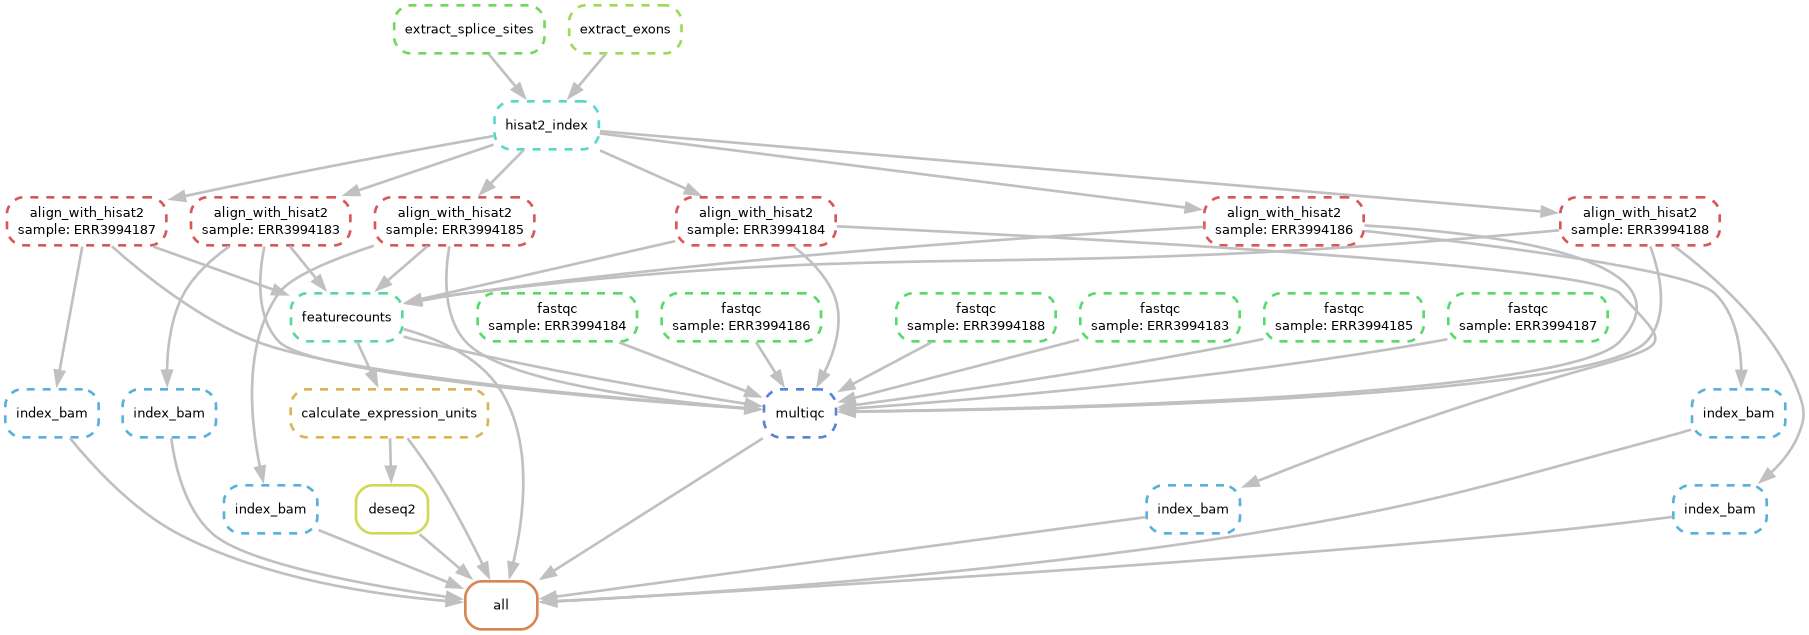

In [23]:

from IPython.display import Image, display
from pathlib import Path

dag = PROJECT_DIR / "dag.png"
if dag.exists():
    display(Image(filename=str(dag)))
else:
    print("DAG image not found")


**Q10.** Look at the DAG. Which rule has the most upstream dependencies? Why?


## 12. Run the workflow

Now run the full pipeline.

This may take a while because the workflow builds the HISAT2 index and aligns six samples. The cut-down FASTQ files are much smaller than the original public RNA-seq files, but Colab runtimes still vary in speed. Rerun the dry-run cell first if you are recovering from an interrupted session.

The `-j 2` option lets Snakemake run up to two jobs at the same time.


In [24]:

%%bash
set -euo pipefail
cd "$PROJECT_DIR"
export PATH="$ENV_PREFIX/bin:/content/bin:$PATH"

snakemake -j 2 --printshellcmds --latency-wait 30


null device 
          1 
null device 
          1 
DESeq2 analysis complete
Results written to: deseq2/deseq2_results_respiratory_vs_fermentative.tsv 


Assuming unrestricted shared filesystem usage.
host: 031aa897849f
Building DAG of jobs...
Using shell: /usr/bin/bash
Provided cores: 2
Rules claiming more threads will be scaled down.
Job stats:
job       count
------  -------
deseq2        1
all           1
total         2

Select jobs to execute...
Execute 1 jobs...

[Thu Apr 30 09:01:16 2026]
localrule deseq2:
    input: quant/gene_counts_matrix.tsv, config/samples.tsv
    output: deseq2/deseq2_results_respiratory_vs_fermentative.tsv, deseq2/deseq2_normalised_counts.tsv, plots/pca.png, plots/ma_plot.png
    jobid: 25
    reason: Missing output files: deseq2/deseq2_results_respiratory_vs_fermentative.tsv, deseq2/deseq2_normalised_counts.tsv, plots/pca.png, plots/ma_plot.png
    resources: tmpdir=/tmp
Shell command: mkdir -p deseq2 plots && Rscript scripts/run_deseq2.R quant/gene_counts_matrix.tsv config/samples.tsv deseq2/deseq2_results_respiratory_vs_fermentative.tsv deseq2/deseq2_normalised_counts.tsv plots/pca.png plots/ma_plot.pn

## 13. Inspect alignment logs and counting summary

HISAT2 writes alignment statistics to log files. featureCounts writes a count summary.

Run the cells below to inspect these outputs.


In [25]:

%%bash
set -euo pipefail
cd "$PROJECT_DIR"
export PATH="$ENV_PREFIX/bin:/content/bin:$PATH"

echo "HISAT2 log files:"
ls -lh logs/hisat2

echo
echo "First HISAT2 log:"
sed -n '1,30p' logs/hisat2/ERR3994183.log

echo
echo "featureCounts summary:"
cat counts/featurecounts.txt.summary


HISAT2 log files:
total 24K
-rw-r--r-- 1 root root 195 Apr 30 08:42 ERR3994183.log
-rw-r--r-- 1 root root 193 Apr 30 08:42 ERR3994184.log
-rw-r--r-- 1 root root 193 Apr 30 08:42 ERR3994185.log
-rw-r--r-- 1 root root 192 Apr 30 08:42 ERR3994186.log
-rw-r--r-- 1 root root 193 Apr 30 08:42 ERR3994187.log
-rw-r--r-- 1 root root 193 Apr 30 08:42 ERR3994188.log

First HISAT2 log:
678 reads; of these:
  678 (100.00%) were unpaired; of these:
    0 (0.00%) aligned 0 times
    678 (100.00%) aligned exactly 1 time
    0 (0.00%) aligned >1 times
100.00% overall alignment rate

featureCounts summary:
Status	bams/ERR3994183.sorted.bam	bams/ERR3994185.sorted.bam	bams/ERR3994187.sorted.bam	bams/ERR3994184.sorted.bam	bams/ERR3994186.sorted.bam	bams/ERR3994188.sorted.bam
Assigned	594	356	530	867	42	178
Unassigned_Unmapped	0	2	1	2	0	1
Unassigned_Read_Type	0	0	0	0	0	0
Unassigned_Singleton	0	0	0	0	0	0
Unassigned_MappingQuality	0	0	0	0	0	0
Unassigned_Chimera	0	0	0	0	0	0
Unassigned_FragmentLength	0	0	0	0	0	

**Q11.** Look at the HISAT2 logs. Do all six samples have similar overall alignment rates? Note any sample that looks different.

**Q12.** In the featureCounts summary, what does the `Assigned` row represent?


## 14. Inspect the raw count matrix and normalisation summary

The raw count matrix has genes as rows and samples as columns. This is the main input to DESeq2.

The normalisation summary also lets us check whether CPM and TPM behaved as expected.


In [26]:

%%bash
set -euo pipefail
cd "$PROJECT_DIR"
export PATH="$ENV_PREFIX/bin:/content/bin:$PATH"

echo "Raw count matrix:"
sed -n '1,8p' quant/gene_counts_matrix.tsv

echo
echo "Normalisation summary:"
cat quant/normalisation_summary.tsv


Raw count matrix:
gene_id	ERR3994183	ERR3994185	ERR3994187	ERR3994184	ERR3994186	ERR3994188
YAL069W	0	0	0	0	0	0
YAL068W-A	0	0	0	0	0	0
YAL068C	0	0	0	0	0	0
YAL067W-A	0	0	0	0	0	0
YAL067C	0	0	0	0	0	0
YAL066W	0	0	0	0	0	0
YAL065C	0	0	0	0	0	0

Normalisation summary:
sample_id	assigned_count_library_size	sum_cpm	sum_tpm
ERR3994183	594	1000000.000	1000000.000
ERR3994185	356	1000000.000	1000000.000
ERR3994187	530	1000000.000	1000000.000
ERR3994184	867	1000000.000	1000000.000
ERR3994186	42	1000000.000	1000000.000
ERR3994188	178	1000000.000	1000000.000


**Q13.** What should the sum of TPM values be for each sample? Check the normalisation summary.

**Q14.** Which sample has the largest assigned-count library size?


## 15. Compare CPM, FPKM and TPM for one gene

The next Python cell reads the count and expression tables and displays values for one gene. You can edit `gene_id` to inspect another gene.


In [27]:

import csv
from pathlib import Path

project = PROJECT_DIR
raw_file = project / "quant" / "gene_counts_matrix.tsv"
cpm_file = project / "quant" / "gene_expression_cpm.tsv"
fpkm_file = project / "quant" / "gene_expression_fpkm.tsv"
tpm_file = project / "quant" / "gene_expression_tpm.tsv"

# Change this to another gene_id after inspecting the count matrix.
gene_id = None

# Pick the first gene if gene_id has not been set.
with raw_file.open() as handle:
    reader = csv.reader(handle, delimiter="\t")
    header = next(reader)
    first_row = next(reader)
    if gene_id is None:
        gene_id = first_row[0]

print("Inspecting gene:", gene_id)

def get_row(path, gene):
    with path.open() as handle:
        reader = csv.DictReader(handle, delimiter="\t")
        for row in reader:
            if row[reader.fieldnames[0]] == gene:
                return row
    return None

for label, path in [("raw counts", raw_file), ("CPM", cpm_file), ("FPKM", fpkm_file), ("TPM", tpm_file)]:
    row = get_row(path, gene_id)
    print("\n" + label)
    for k, v in row.items():
        print(f"{k}\t{v}")


Inspecting gene: YAL069W

raw counts
gene_id	YAL069W
ERR3994183	0
ERR3994185	0
ERR3994187	0
ERR3994184	0
ERR3994186	0
ERR3994188	0

CPM
gene_id	YAL069W
ERR3994183	0.000000
ERR3994185	0.000000
ERR3994187	0.000000
ERR3994184	0.000000
ERR3994186	0.000000
ERR3994188	0.000000

FPKM
gene_id	YAL069W
ERR3994183	0.000000
ERR3994185	0.000000
ERR3994187	0.000000
ERR3994184	0.000000
ERR3994186	0.000000
ERR3994188	0.000000

TPM
gene_id	YAL069W
ERR3994183	0.000000
ERR3994185	0.000000
ERR3994187	0.000000
ERR3994184	0.000000
ERR3994186	0.000000
ERR3994188	0.000000


**Q15.** For the gene you inspected, do CPM, FPKM and TPM tell exactly the same story as raw counts? Explain why the values differ.


## 16. Inspect DESeq2 results

DESeq2 compares respiratory growth against fermentative growth. In the results table:

- `baseMean` is the average normalised count across samples;
- `log2FoldChange` is the estimated log2 fold change for respiratory vs fermentative;
- positive log2 fold change means higher in respiratory growth;
- negative log2 fold change means higher in fermentative growth;
- `pvalue` is the test p-value;
- `padj` is the multiple-testing-adjusted p-value.

Run the cell below to view the most significant genes.


In [28]:

%%bash
set -euo pipefail
cd "$PROJECT_DIR"
export PATH="$ENV_PREFIX/bin:/content/bin:$PATH"

echo "Top DESeq2 results:"
head -n 20 deseq2/deseq2_results_respiratory_vs_fermentative.tsv

echo
echo "Number of genes with adjusted p-value < 0.05:"
awk 'NR > 1 && $7 != "NA" && $7 < 0.05 {n++} END {print n+0}' deseq2/deseq2_results_respiratory_vs_fermentative.tsv


Top DESeq2 results:
gene_id	baseMean	log2FoldChange	lfcSE	stat	pvalue	padj
21S_rRNA	183.437354516811	-0.876856656536705	0.335297042866138	-2.61516370392439	0.00891846987537227	0.107021638504467
Q0055	12.9745484201237	-0.961434706964381	0.63241819858375	-1.52025148725549	0.128447781608367	0.352500354356499
Q0085	2.23885796700553	1.90200023129999	1.25901980279187	1.51069921782192	0.130865101801374	0.352500354356499
Q0130	7.19438868915269	1.15120236848312	0.793572612090629	1.45065788680678	0.146875147648541	0.352500354356499
Q0160	3.54680852316498	-1.66690675943624	0.939114170600721	-1.7749777520341	0.0759015607666917	0.352500354356499
Q0275	4.02896350134712	0.977474331384531	0.929802290045164	1.05127115930963	0.293134069115904	0.586268138231807
Q0120	2.25987507109618	1.13166658227833	1.20264611624917	0.94098053200204	0.346714835850594	0.59436829002959
Q0250	2.65911699890185	-0.808468047189171	1.07027280559163	-0.755385022365638	0.450017997351043	0.675026996026564
15S_rRNA	55.061517084096

**Q16.** Pick two genes with `padj < 0.05`: one with positive log2 fold change and one with negative log2 fold change. Which condition is each gene more highly expressed in?

**Q17.** Why do we use an adjusted p-value rather than just the raw p-value when testing thousands of genes?


## 17. View diagnostic plots

The PCA plot checks whether samples group by condition. The MA plot shows log fold change against mean expression.


pca.png


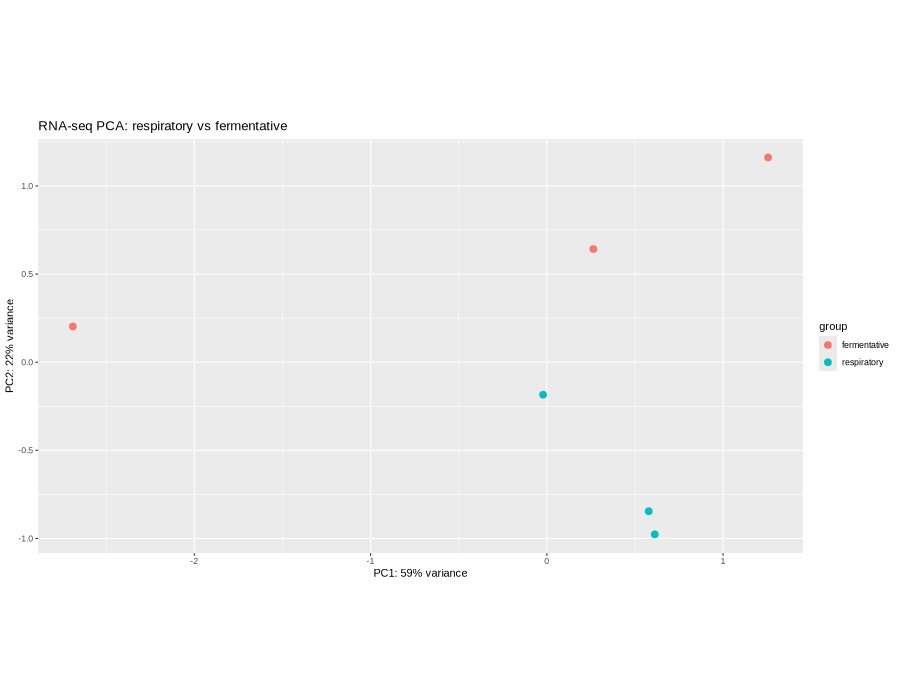

ma_plot.png


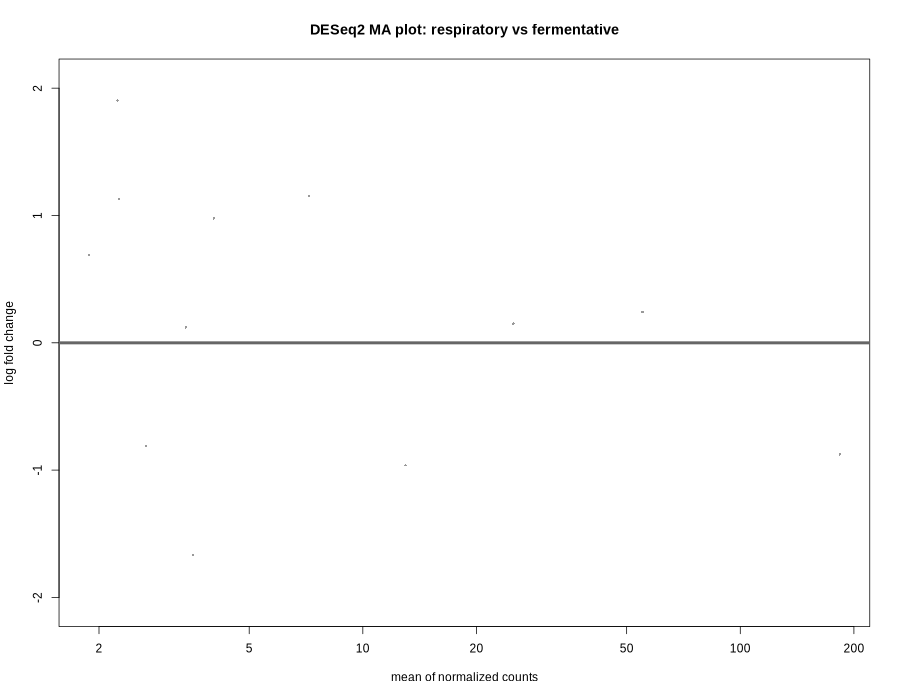

In [29]:

from IPython.display import Image, display
from pathlib import Path

for plot in [PROJECT_DIR / "plots" / "pca.png", PROJECT_DIR / "plots" / "ma_plot.png"]:
    if plot.exists():
        print(plot.name)
        display(Image(filename=str(plot)))
    else:
        print("Missing:", plot)


**Q18.** Do the respiratory and fermentative samples separate in the PCA plot? What does that suggest about the experiment?


## 18. Going further

Try one or more of the following:

1. Open `qc/multiqc_report.html` and inspect the FastQC, HISAT2 and featureCounts summaries.
2. Change the gene-count filtering threshold in `run_deseq2.R` from `rowSums(counts(dds)) >= 10` to another value. Rerun Snakemake. How do the DESeq2 results change?
3. Add a Snakemake rule that creates a table of the top 20 genes by absolute log2 fold change.
4. Add a rule that compresses the final output tables into a `results.tar.gz` archive.
5. Use `snakemake -n` after deleting one output file. Which rules would rerun?

## Summary

In this practical you ran a complete RNA-seq expression workflow in Snakemake. You used raw reads, a reference genome and a gene annotation file to generate a gene-count matrix. You then created CPM, FPKM and TPM tables and used raw counts for DESeq2 differential expression.

The important conceptual shift from the DNA practicals is that the endpoint is no longer a VCF file. In RNA-seq expression analysis, the central data object is a matrix of counts per gene per sample.
